In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("\nDataset Information")
print("-------------------")
print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)

print("\nPixel value range before normalization:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset Information
-------------------
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)

Pixel value range before normalization:
Minimum: 0
Maximum: 255


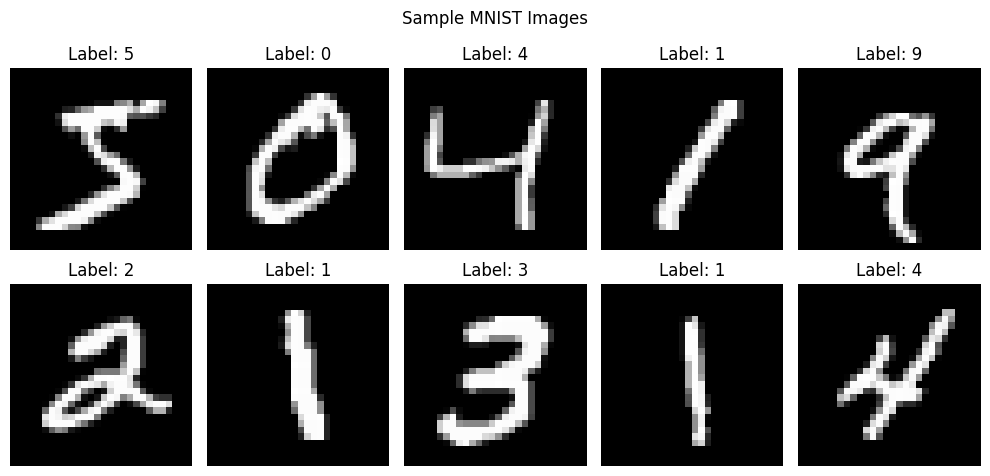

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

In [5]:
unique, counts = np.unique(y_train, return_counts=True)

print("\nClass Distribution")
print("------------------")

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")


Class Distribution
------------------
Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


In [6]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("\nPixel value range after normalization:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())


Pixel value range after normalization:
Minimum: 0.0
Maximum: 1.0


In [7]:
model = tf.keras.Sequential([

    # Input image: 28 x 28
    tf.keras.layers.Input(shape=(28, 28)),

    # Convert 28x28 image into 784 values
    tf.keras.layers.Flatten(),

    # Hidden layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer
    # 10 neurons = digits 0 to 9
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

In [8]:
print("\nOriginal Model Architecture")
print("---------------------------")

model.summary()


Original Model Architecture
---------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
print("\nTraining Original Model...")
print("--------------------------")

history = model.fit(
    x_train,
    y_train,

    # Number of times the complete dataset is used
    epochs=10,

    # Number of images processed at once
    batch_size=32,

    # 20% of training data used for validation
    validation_split=0.2
)



Training Original Model...
--------------------------
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9182 - loss: 0.2881 - val_accuracy: 0.9538 - val_loss: 0.1571
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9633 - loss: 0.1251 - val_accuracy: 0.9647 - val_loss: 0.1194
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9747 - loss: 0.0845 - val_accuracy: 0.9721 - val_loss: 0.0952
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9810 - loss: 0.0630 - val_accuracy: 0.9725 - val_loss: 0.0928
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9849 - loss: 0.0483 - val_accuracy: 0.9736 - val_loss: 0.0865
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9884 - loss: 0.0380 - val_accuracy: 0.9753 - val_loss: 0.0821
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9909 - loss: 0.0302 - val_accuracy: 0.9746 - val_loss: 0.0885
Epoch 8/10
1500/1500 ━━━━━━━━━━━━

In [11]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nOriginal Model Results")
print("----------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


Original Model Results
----------------------
Test Loss     : 0.0800
Test Accuracy : 97.76%


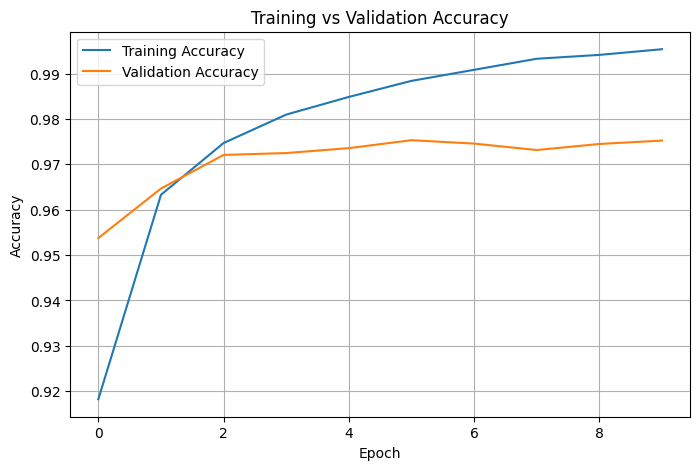

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

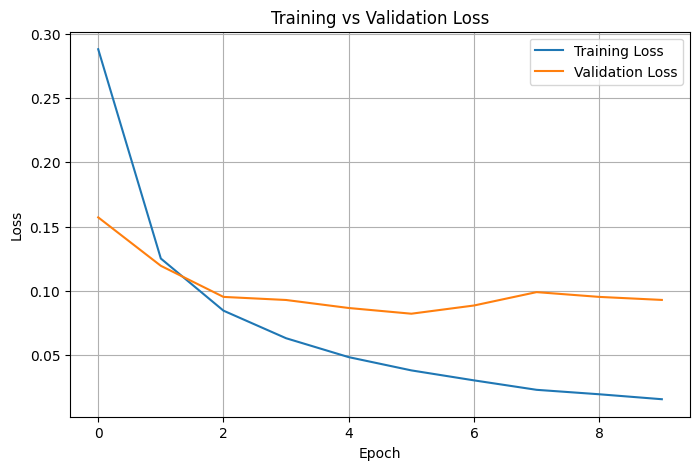

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
sample_images = x_test[:5]
actual_labels = y_test[:5]

# Make predictions
predictions = model.predict(
    sample_images,
    verbose=0
)

# Convert probabilities to predicted digit
predicted_labels = np.argmax(
    predictions,
    axis=1
)

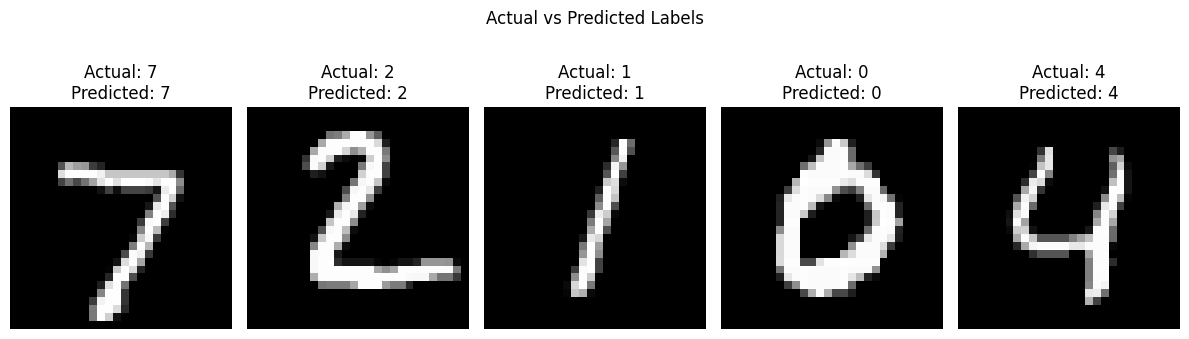

In [15]:
plt.figure(figsize=(12, 4))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        sample_images[i],
        cmap="gray"
    )

    plt.title(
        f"Actual: {actual_labels[i]}\n"
        f"Predicted: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.suptitle("Actual vs Predicted Labels")
plt.tight_layout()
plt.show()


In [16]:
print("\nPrediction Results")
print("------------------")

print("Image\tActual\tPredicted\tResult")

for i in range(5):

    result = (
        "Correct"
        if actual_labels[i] == predicted_labels[i]
        else "Wrong"
    )

    print(
        f"{i + 1}\t"
        f"{actual_labels[i]}\t"
        f"{predicted_labels[i]}\t\t"
        f"{result}"
    )



Prediction Results
------------------
Image	Actual	Predicted	Result
1	7	7		Correct
2	2	2		Correct
3	1	1		Correct
4	0	0		Correct
5	4	4		Correct


In [17]:
print("\n\nExperiment: Adding Dropout")
print("===========================")



Experiment: Adding Dropout


In [18]:
dropout_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(28, 28)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout experiment
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])


In [19]:
dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [20]:
print("\nTraining Dropout Model...")
print("-------------------------")

dropout_history = dropout_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)



Training Dropout Model...
-------------------------
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9057 - loss: 0.3268 - val_accuracy: 0.9557 - val_loss: 0.1560
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9540 - loss: 0.1565 - val_accuracy: 0.9642 - val_loss: 0.1189
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9646 - loss: 0.1168 - val_accuracy: 0.9703 - val_loss: 0.0979
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9713 - loss: 0.0955 - val_accuracy: 0.9716 - val_loss: 0.0981
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9751 - loss: 0.0800 - val_accuracy: 0.9732 - val_loss: 0.0925
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9777 - loss: 0.0703 - val_accuracy: 0.9751 - val_loss: 0.0887
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9812 - loss: 0.0598 - val_accuracy: 0.9742 - val_loss: 0.0863
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━

In [21]:
dropout_loss, dropout_accuracy = dropout_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

In [22]:
print("\n\nMODEL COMPARISON")
print("================")

print(
    f"Original Model Test Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Dropout Model Test Accuracy  : "
    f"{dropout_accuracy * 100:.2f}%"
)

print(
    f"\nOriginal Model Best "
    f"Validation Accuracy: "
    f"{max(history.history['val_accuracy']) * 100:.2f}%"
)

print(
    f"Dropout Model Best "
    f"Validation Accuracy: "
    f"{max(dropout_history.history['val_accuracy']) * 100:.2f}%"
)




MODEL COMPARISON
Original Model Test Accuracy : 97.76%
Dropout Model Test Accuracy  : 97.80%

Original Model Best Validation Accuracy: 97.53%
Dropout Model Best Validation Accuracy: 97.76%


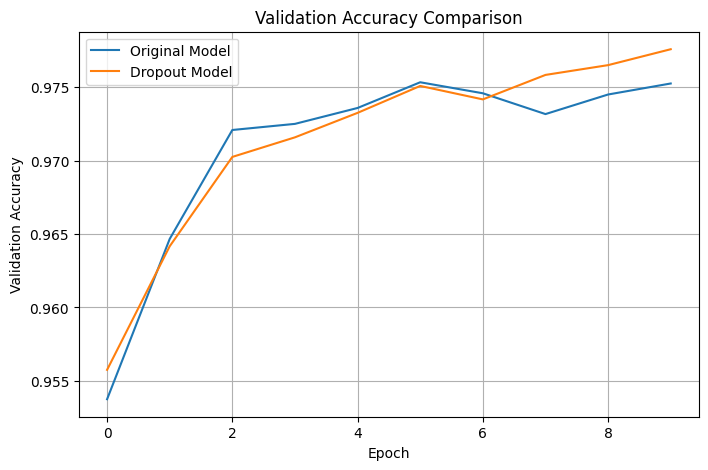

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    label="Original Model"
)

plt.plot(
    dropout_history.history["val_accuracy"],
    label="Dropout Model"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


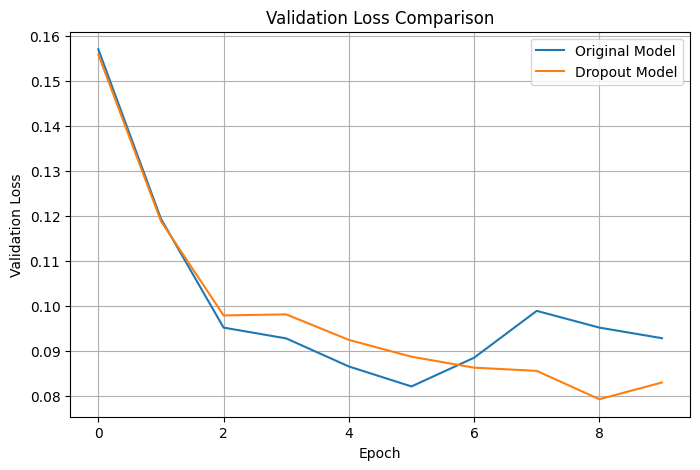

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Original Model"
)

plt.plot(
    dropout_history.history["val_loss"],
    label="Dropout Model"
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [25]:
print("\n")
print("=" * 50)
print("FINAL RESULTS")
print("=" * 50)

print(
    f"Original Model Accuracy : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Dropout Model Accuracy  : "
    f"{dropout_accuracy * 100:.2f}%"
)

print("=" * 50)



FINAL RESULTS
Original Model Accuracy : 97.76%
Dropout Model Accuracy  : 97.80%
